In [120]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# # 1. Check if MPS (Metal Performance Shaders) is available on your Mac
# if torch.backends.mps.is_available():
#     # 2. Set MPS as the global default device for all new tensors
#     torch.set_default_device("mps")


with open("names.txt", "r") as f:
    names = f.read().splitlines()

# print 5 sample names
names[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [121]:
# total number of names in dataset
len(names)

32033

In [122]:
# Create data sets (the input n-gram and corresponding expected label)
NGRAM_SIZE = 3 # The n in n-gram

# Map characters to integer indices ('.' is the boundary/padding token)
chars = ['.'] + sorted(set(''.join(names)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

X = []
Y = []
for name in names:
    window = "." * NGRAM_SIZE
    for ch in name + ".":
        X.append([stoi[c] for c in window])
        Y.append(stoi[ch])
        #print(f"{window} -> {ch}")
        window = window[1:] + ch

vocab_size = len(chars)

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape, len(chars)

(torch.Size([228146, 3]), torch.Size([228146]), 27)

In [158]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Linear:
    def __init__ (self, in_features, out_features, bias=True):
        k = 1/in_features
        upper = k ** 0.5
        lower = -(k ** 0.5)
        self.weight = (upper - lower) * torch.rand((in_features, out_features)) + lower
        self.bias = None if bias is False else torch.zeros((1, out_features))

    def __call__ (self, x): # x is typically of shape (batchsize, in_features)
        """ output is of the shape (batchsize, out_features) """
        self.out = x @ self.weight
        if self.bias is not None:
            self.out = self.out + self.bias
        return self.out

    def parameters (self):
        # Return the leaf tensors themselves. Iterating over self.weight would
        # yield row *views*, which are not leaves, so their .grad stays None.
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm:
    def __init__(self, out_features, eps=1e-05, momentum=0.1, mode="train"):
        self.eps = eps
        self.gamma = torch.ones((1, out_features))
        self.beta = torch.zeros((1, out_features))
        self.momentum = momentum
        self.out_features = out_features
        self.mode = mode
        self.running_mean = torch.zeros((1, self.out_features))
        self.running_variance = torch.ones(1, self.out_features)

    def __call__(self, x):
        """
        Input shape: (batchsize, featuresize)
        Output shape: (batchsize, featuresize) - same shape as the input
        """
        if self.mode == "eval":
            mean = self.running_mean
            variance = self.running_variance
        elif self.mode == "train":
            mean = torch.mean(x, dim=0, keepdim=True) # size = 1, featuresize
            variance = torch.var(x, dim=0, keepdim=True) # size = 1, featuresize
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
                self.running_variance = (1 - self.momentum) * self.running_variance + self.momentum * variance
        xhat = (x - mean) / ((variance + self.eps) ** 0.5) # size = batchsize, featuresize
        self.out = (self.gamma * xhat) + self.beta # size = batchsize, featuresize
        return self.out

    def parameters(self):
        params = []
        params.append(self.gamma)
        params.append(self.beta)
        return params


In [159]:
# Training split and validation split (90 - 10)
TRAINING_SPLIT = 0.9
shuffled_indexes = torch.randperm(X.shape[0])

# training set
n_train = int(TRAINING_SPLIT * X.shape[0])
train_indexes = shuffled_indexes[:n_train]
X_train = X[train_indexes]
Y_train = Y[train_indexes]

# validation set
validation_indexes = shuffled_indexes[n_train:]
X_validate = X[validation_indexes]
Y_validate = Y[validation_indexes]


In [164]:
# Instantiate the neural net

torch.manual_seed(100)
EMBEDDING_DIMENSIONS = 10
MINIBATCH_SIZE = 64

def eval_loss(Xe, Ye):
    for layer in  layers:
        if isinstance(layer, BatchNorm):
            layer.mode = "eval"

    one_hot = F.one_hot(Xe, num_classes=vocab_size).float()
    x = (one_hot @ C).view(-1, EMBEDDING_DIMENSIONS * NGRAM_SIZE)
    for layer in layers:
        x = layer(x)

    for layer in  layers:
        if isinstance(layer, BatchNorm):
            layer.mode = "train"

    return F.cross_entropy(x, Ye).item()

C = torch.randn((vocab_size, EMBEDDING_DIMENSIONS))

# instantiate the net
layers = [
    Linear (EMBEDDING_DIMENSIONS * NGRAM_SIZE, 200, bias=False),
    BatchNorm(200),
    Tanh(),
    Linear (200, 200, bias=False), 
    BatchNorm(200), 
    Tanh(),
    Linear (200, 200, bias=False),
    BatchNorm(200), 
    Tanh(),
    Linear (200, 200, bias=False), 
    BatchNorm(200), 
    Tanh(),
    Linear (200, 200, bias=False), 
    BatchNorm(200), 
    Tanh(),
    Linear(200, vocab_size)
    ]

# with torch.no_grad():
#     for p in layers[-1].parameters():
#         p *= 0.1

parameters = []
parameters.append(C)
for layer in layers:
    for p in layer.parameters():
        parameters.append(p)

for p in parameters:
    p.requires_grad = True

best_val = float('inf')
best_snapshot = None
best_bn_stats = None
best_gradients = None

In [ ]:
# training loop
for layer in  layers:
    if isinstance(layer, BatchNorm):
        layer.mode = "train"

ud = []  # per-step update:data ratios; each row is log10((lr*grad).std()/weight.std()) aligned with `parameters`

for i in range(100000):

    # construct a batch instead of training on all examples
    batch_indexes = torch.randint(0, X_train.size(0), (MINIBATCH_SIZE,))
    
    # lookup embeddings
    one_hot = F.one_hot(X_train[batch_indexes], num_classes=vocab_size).float() # (32, 3, 27)
    x = one_hot @ C # (32, 3, 2)

    # first linear layer is a layer of 6 neurons
    x = x.view(-1, EMBEDDING_DIMENSIONS * NGRAM_SIZE)

    # call the neural net
    for layer in layers:
        x = layer(x)
    
    # compute loss
    loss = F.cross_entropy(x, Y_train[batch_indexes])

    # compute gradients
    loss.backward()

    # decay the LR as we get better
    if i >= 50000:
        lr = 0.03
    else:
        lr = 0.1

    # adjust weights based on the gradients
    for p in parameters:
        p.data += -lr * p.grad

    # record this step's update:data ratio (aligned with `parameters`) for the ud plot
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

    # snapshot the best loss and parameters on the validation set
    with torch.no_grad():
        if i % 1000 == 0:
            vl = eval_loss(X_validate, Y_validate)
            if vl < best_val:
                best_val = vl
                best_weights = [p.detach().clone() for p in parameters]
                best_gradients = [p.grad.detach().clone() for p in parameters]
                # also snapshot BatchNorm running stats (buffers, not in `parameters`)
                # so eval/sample-time normalization matches the loss measured here
                best_bn_stats = [(l.running_mean.clone(), l.running_variance.clone())
                                 for l in layers if isinstance(l, BatchNorm)]
                print(f"{i}: current minibatch loss {loss:.4f} | best validation loss {best_val:.4f}")

    # reset gradients to get ready for next pass
    for p in parameters:
        p.grad = None
        

0: current minibatch loss 3.3999 | best validation loss 3.2831
1000: current minibatch loss 2.4000 | best validation loss 2.3278
2000: current minibatch loss 2.2532 | best validation loss 2.2738
3000: current minibatch loss 2.2996 | best validation loss 2.2375
4000: current minibatch loss 2.2415 | best validation loss 2.2242
5000: current minibatch loss 1.9610 | best validation loss 2.2166
6000: current minibatch loss 2.2441 | best validation loss 2.1954
8000: current minibatch loss 2.0332 | best validation loss 2.1896
9000: current minibatch loss 2.4594 | best validation loss 2.1878
11000: current minibatch loss 2.1028 | best validation loss 2.1812
13000: current minibatch loss 2.2888 | best validation loss 2.1604
16000: current minibatch loss 2.3330 | best validation loss 2.1464
18000: current minibatch loss 2.1187 | best validation loss 2.1441
20000: current minibatch loss 1.8612 | best validation loss 2.1327
28000: current minibatch loss 2.1177 | best validation loss 2.1223
35000: 

In [166]:
for best_gradient in best_gradients:
    print(best_gradient.shape)

torch.Size([27, 10])
torch.Size([30, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([200, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([200, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([200, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([200, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([200, 27])
torch.Size([1, 27])


In [167]:
# Restore the best snapshot (lowest validation loss) into the live network.
# `parameters` holds the same leaf tensors the layers use, in the same order as
# `best_weights`, so an in-place copy updates the model. BatchNorm running stats
# are buffers (not in `parameters`), so restore them separately — otherwise the
# eval/sample-time forward pass won't reproduce the loss we actually measured.
with torch.no_grad():
    for p, snap in zip(parameters, best_weights):
        p.copy_(snap)
    bn_layers = [l for l in layers if isinstance(l, BatchNorm)]
    for l, (rm, rv) in zip(bn_layers, best_bn_stats):
        l.running_mean = rm.clone()
        l.running_variance = rv.clone()

print(f"restored best snapshot (validation loss {best_val:.4f})")


restored best snapshot (validation loss 2.0727)


layer 2 torch.Size([1000, 200]) (   Tanh   ): mean -0.00 std 0.65, saturated: 10.06%
layer 5 torch.Size([1000, 200]) (   Tanh   ): mean +0.00 std 0.68, saturated: 11.43%
layer 8 torch.Size([1000, 200]) (   Tanh   ): mean -0.00 std 0.70, saturated: 10.68%
layer 11 torch.Size([1000, 200]) (   Tanh   ): mean +0.00 std 0.73, saturated:  9.09%
layer 14 torch.Size([1000, 200]) (   Tanh   ): mean +0.01 std 0.65, saturated:  3.30%

layer 2 torch.Size([1000, 200]) (   Tanh   ): mean -2.17e-07 std 5.71e-05
layer 5 torch.Size([1000, 200]) (   Tanh   ): mean -1.04e-07 std 6.24e-05
layer 8 torch.Size([1000, 200]) (   Tanh   ): mean -4.83e-08 std 6.20e-05
layer 11 torch.Size([1000, 200]) (   Tanh   ): mean +8.28e-08 std 5.92e-05
layer 14 torch.Size([1000, 200]) (   Tanh   ): mean +1.27e-07 std 1.07e-04



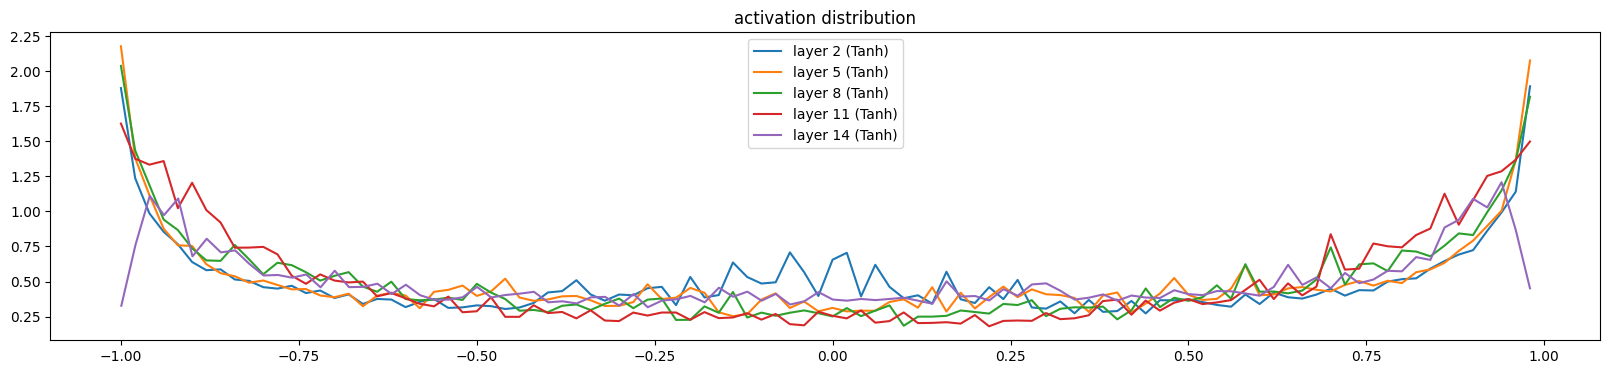

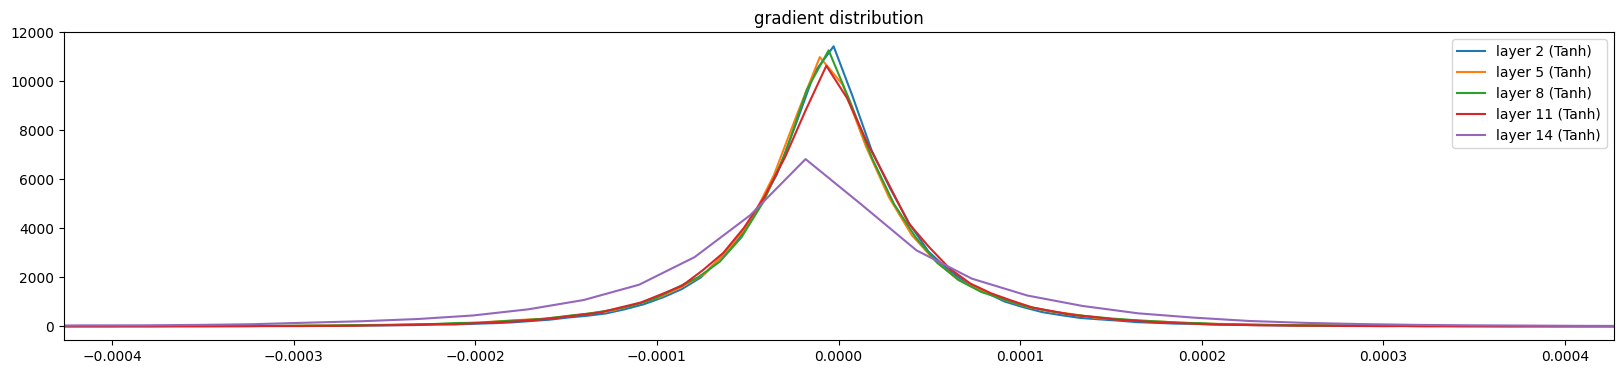

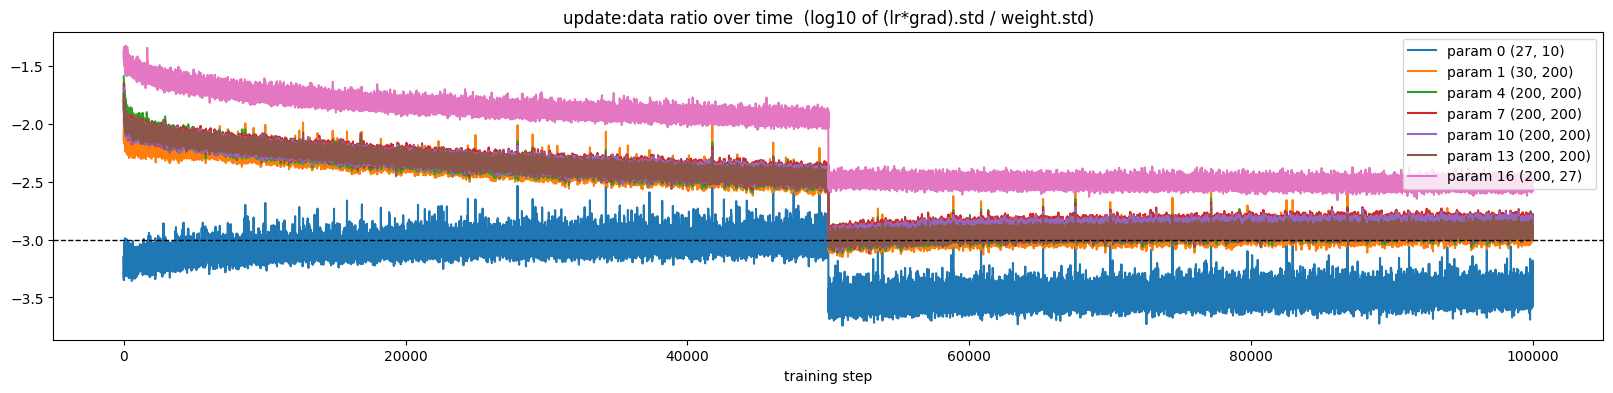

In [168]:
# DIAGNOSTICS

# freeze BatchNorm (use running stats, don't update them) and clear stale grads
for layer in layers:
    if isinstance(layer, BatchNorm):
        layer.mode = "eval"

for p in parameters:
    p.grad = None

# Forward pass WITH grad enabled (no torch.no_grad here) so we can read the
# activation gradients. retain_grad() keeps .grad on the non-leaf tanh outputs.
batch_indexes = torch.randint(0, X_validate.size(0), (1000,))
one_hot = F.one_hot(X_validate[batch_indexes], num_classes=vocab_size).float()  # (1000, 3, 27)
x = (one_hot @ C).view(-1, EMBEDDING_DIMENSIONS * NGRAM_SIZE)                    # (1000, 30)
for layer in layers:
    x = layer(x)
    if isinstance(layer, Tanh):
        layer.out.retain_grad()

# a loss + backward is required to actually populate the retained gradients
loss = F.cross_entropy(x, Y_validate[batch_indexes])
loss.backward()

tanh_layers = [(i, layer) for i, layer in enumerate(layers[:-1]) if isinstance(layer, Tanh)]

# PLOT 1
# activation distribution (karpathy makemore3 style)
plt.figure(figsize=(20, 4))
legends = []
for (i, layer) in tanh_layers:
    t = layer.out
    print(f'layer {i} {t.shape} ({layer.__class__.__name__:^10}): mean {t.mean():+.2f} std {t.std():.2f}, saturated: {(t.abs() > 0.97).float().mean()*100:>5.2f}%')
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

# PLOT 2
# gradient distribution: grads are tiny so print in scientific notation; the
# |x|>0.97 "saturated" metric is meaningless for unbounded gradients, so omit it.
print()
plt.figure(figsize=(20, 4))
legends = []
for (i, layer) in tanh_layers:
    t = layer.out.grad
    print(f'layer {i} {t.shape} ({layer.__class__.__name__:^10}): mean {t.mean():+.2e} std {t.std():.2e}')
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')
xmax = 4 * max(layer.out.grad.std().item() for (_, layer) in tanh_layers)
plt.xlim(-xmax, xmax)
plt.legend(legends)
plt.title('gradient distribution')

# PLOT 3
# update:data ratio over training (karpathy makemore3 "ud" plot). `ud` was recorded
# each training step: ud[t] is a row aligned with `parameters`, holding
# log10((lr*grad).std() / weight.std()). We plot each weight matrix's history over
# time; healthy training converges toward ~ -3 (the dashed reference line). A line
# sitting well above -3 means steps are large relative to the weights; well below
# means that matrix is barely learning.
print()
plt.figure(figsize=(20, 4))
ud_legends = []
for j, p in enumerate(parameters):
    if p.ndim == 2 and p.shape[0] > 1:   # weight matrices only (skip (1, N) gamma/beta/bias)
        plt.plot([row[j] for row in ud])
        ud_legends.append(f'param {j} {tuple(p.shape)}')
plt.axhline(-3, color='k', linestyle='--', linewidth=1)   # healthy reference
plt.legend(ud_legends)
plt.xlabel('training step')
plt.title('update:data ratio over time  (log10 of (lr*grad).std / weight.std)')

# clear the grads this diagnostic produced so they don't leak into a later run
for p in parameters:
    p.grad = None

In [115]:
len(best_gradients)

18

In [169]:
# sample the neural net to get name sounding things ...

for layer in  layers:
    if isinstance(layer, BatchNorm):
        layer.mode = "eval"


g = torch.Generator().manual_seed(10101)
for _ in range(20):
    out = []
    context = [0] * 3
    context = torch.tensor(context)
    while True:
        one_hot = F.one_hot(context, num_classes=vocab_size).float()
        x = one_hot @ C

        # lookup embedding to feed into the neural net
        x = x.view(-1, EMBEDDING_DIMENSIONS * NGRAM_SIZE)

        for layer in layers:
            x = layer(x)

        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = torch.cat([context[1:], torch.tensor([ix])])
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))


anna.
kenda.
zey.
ly.
nalissatheram.
mare.
ana.
andustell.
nayianalen.
leislynn.
adhriya.
bhammille.
naomi.
aeha.
arsterixxon.
adanis.
alean.
kham.
neem.
keyrus.
